In [5]:
import pandas as pd
import pickle
import matplotlib.pyplot as plt

In [7]:
#read pickle file
with open('../tracker_stubs/ball_detections.pkl', 'rb') as f:
    ball_positions = pickle.load(f)

In [8]:
ball_positions = [x.get(1,[]) for x in ball_positions]
df_ball_positions = pd.DataFrame(ball_positions, columns=["x1", "y1", "x2", "y2"]) #convert list to pandas dataframe

#interpolate missing values
df_ball_positions = df_ball_positions.interpolate()
df_ball_positions = df_ball_positions.bfill()

In [ ]:
df_ball_positions['mid_y'] = (df_ball_positions['y1'] + df_ball_positions['y2'])/2 #calculate mid y position of ball
df_ball_positions['mid_y_rolling_mean'] = df_ball_positions['mid_y'].rolling(window=5, min_periods=1, center=False).mean() #calculate rolling mean of mid y position of ball


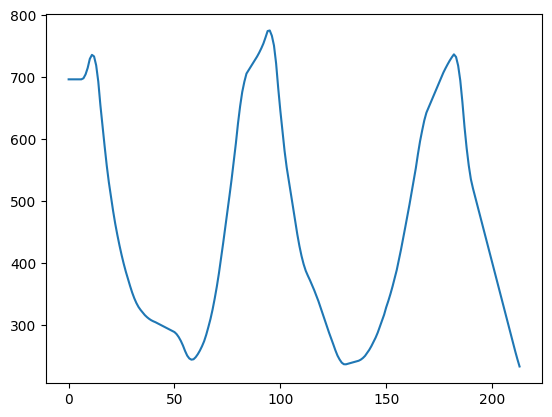

In [ ]:
#plot mid y rolling mean
plt.plot(df_ball_positions['mid_y_rolling_mean'])

#everytime the curve changes direction, the ball is hit

In [15]:
df_ball_positions['delta_y'] = df_ball_positions['mid_y_rolling_mean'].diff() #calculate difference between consecutive mid y positions

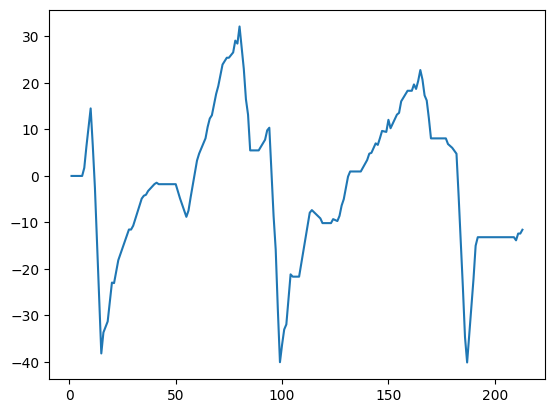

In [16]:
#plot delta y
plt.plot(df_ball_positions['delta_y'])

In [17]:
df_ball_positions['ball_hit'] = 0

In [ ]:

min_change_frames_for_hit = 25 # at least 25 frames must pass between hits

for i in range(1, len(df_ball_positions) - int(min_change_frames_for_hit*1.2)): #iterate through all frames and put a buffer of 20%
    negative_position_change = df_ball_positions['delta_y'].iloc[i] > 0 and df_ball_positions['delta_y'].iloc[i+1] < 0 #if the curve changes direction from positive to negative
    positive_position_change = df_ball_positions['delta_y'].iloc[i] < 0 and df_ball_positions['delta_y'].iloc[i+1] > 0 #if the curve changes direction from negative to positive

    if negative_position_change or positive_position_change:
        change_count = 0
        for change_frame in range(i+1, i+int(min_change_frames_for_hit*1.2)+1):
            negative_position_change_in_following_frame = df_ball_positions['delta_y'].iloc[i] > 0 and df_ball_positions['delta_y'].iloc[change_frame] < 0 
            positive_position_change_in_following_frame = df_ball_positions['delta_y'].iloc[i] < 0 and df_ball_positions['delta_y'].iloc[change_frame] > 0

            if negative_position_change and negative_position_change_in_following_frame:
                change_count += 1
            elif positive_position_change and positive_position_change_in_following_frame:
                change_count += 1

        if change_count >= min_change_frames_for_hit-1:
            df_ball_positions['ball_hit'].iloc[i] = 1

    
frame_nums_with_ball_hits = df_ball_positions[df_ball_positions['ball_hit'] == 1].index.tolist() #get frame numbers where ball is hit


C:\Users\livan\AppData\Local\Temp\ipykernel_12992\388746407.py:19: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df_ball_positions['ball_hit'].iloc[i] = 1
C:\Users\livan\AppData\Local\Temp\ipykernel_12992\388746407.py:19: SettingWithCopyWarn

In [ ]:
df_ball_positions[df_ball_positions['ball_hit'] == 1]   #print all frames where the ball is hit

,x1,y1,x2,y2,mid_y,mid_y_rolling_mean,delta_y,ball_hit
11,777.629944,718.681824,797.461182,740.250916,729.466370,736.438623,6.509393,1
58,925.599304,242.704178,937.552942,253.983914,248.344046,244.361675,-1.971447,1
95,622.992401,748.583771,641.837158,768.347809,758.465790,775.804053,0.902533,1
131,717.311975,231.712213,730.913489,245.864691,238.788452,236.869499,-0.146800,1
182,1294.562744,738.239685,1313.439453,757.288147,747.763916,737.287372,4.776483,1


In [ ]:
frame_nums_with_ball_hits = df_ball_positions[df_ball_positions['ball_hit'] == 1].index.tolist() #get frame numbers where ball is hit